#PCA(主成分分析)
##多変量データの情報をなるべく失わずに次元を削減する方法。
##ばらつきが最大になる方向を新たな軸にする

6つの調査区において、異なる三種の被度を測定。これらの群集の組成がどれほど似通っているのかを主成分分析を用いて表現する

In [ ]:
import numpy as np
###
#サンプルデータ 
#三種の植物の被度データ(行：調査区　　列:種)
#
x=np.array([
    [10,20,30],
    [15,24,33],
    [14,22,31],
    [30,10,5],
    [28,12,7],
    [32,9,4]
])


In [ ]:
標準化
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_std=scaler.fit_transform(x)
x_std

array([[-1.31986428,  0.63766002,  0.89333398],
       [-0.74601024,  1.30304439,  1.12304843],
       [-0.86078105,  0.9703522 ,  0.96990547],
       [ 0.97555186, -1.0258009 , -1.02095312],
       [ 0.74601024, -0.69310872, -0.86781015],
       [ 1.20509347, -1.19214699, -1.09752461]])

In [6]:
#PCAの実行
from sklearn.decomposition import PCA
pca=PCA(n_components=2)#二次元に圧縮
x_pca=pca.fit_transform(x_std)

In [ ]:
#主成分得点(座標)
print(x_pca)

[[ 1.64406848 -0.49368644]
 [ 1.83302083  0.39462355]
 [ 1.61766662  0.07757623]
 [-1.74509392 -0.03096837]
 [-1.33264728  0.0212876 ]
 [-2.01701473  0.03116743]]


In [ ]:
#寄与率　どれほど説明しているか
print(pca.explained_variance_ratio_)

[0.97607899 0.02265865]


PC1で97%説明できる

In [9]:
#主成分負荷量 各種がどの主成分にどれほど効くか
print(pca.components_)

[[-0.57242326  0.57628174  0.5832932 ]
 [ 0.76904385  0.62409506  0.13811922]]


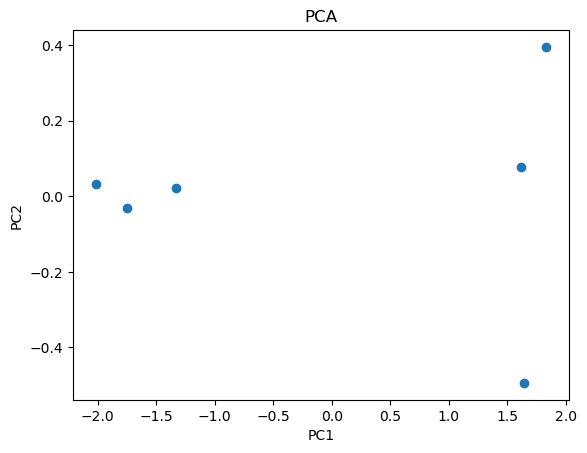

In [ ]:
#可視化
import matplotlib.pyplot as plt
plt.scatter(x_pca[:,0],x_pca[:,1])

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA')
plt.show()

三次元の情報を二次元に圧縮している。
点の配置が近い→種組成が似ている。同じような被度を持つ
遠い→違う群集である

主成分負荷量とは
各変数（種や環境要因）が主成分にどれだけ寄与しているかを表す係数

イメージ
PC1=0.7*種A　+　0.6*種B　-　0.3*種C
このとき　0.7 0.6 0.3　が主成分負荷量
絶対値が大きいほどその変数がその主成分に強く効いている=軸の向き
このサンプルの場合、種Aのばらつきの方向に軸がつよく傾いている
